In [1]:
# ============================================================================
# Analyze Fine-tuning Loss Curves
# ============================================================================
# This notebook visualizes training and validation loss curves for fine-tuned
# Akita models. It can plot:
# - A single model's loss curve
# - All models from a dataset in separate subplots
# ============================================================================

In [2]:
# %% Setup Python Path
import os
import sys

# Add parent directory to Python path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
    print(f"Added to Python path: {parent_dir}")

# %% Imports

import matplotlib.pyplot as plt

from utils import find_all_models, load_loss_file, plot_all_models, plot_single_model

Added to Python path: /home1/smaruj/pytorch_akita


### Configuration

In [3]:
# Base path for loss files
BASE_PATH = "/scratch1/smaruj/Akita_pytorch_models"

# Dataset to analyze
ORGANISM = "mouse"              # "mouse" or "human"
DATASET_NAME = "Hsieh2019_mESC" # Dataset name
NUM_MODELS = 8                  # Number of model splits (0 to NUM_MODELS-1)

# Plotting options
PLOT_SINGLE = False             # If True, plot only a single model
SINGLE_MODEL_IDX = 1            # Which model to plot if PLOT_SINGLE=True
SAVE_FIGURE = False             # Save figure as SVG
OUTPUT_FILE = "/plots/example_finetuning_loss_curves.svg"  # Output filename

### Main Execution

Analyzing Fine-tuning Loss Curves
Organism: mouse
Dataset: Hsieh2019_mESC

Finding all available models...
Found 8 models: [0, 1, 2, 3, 4, 5, 6, 7]


Done!


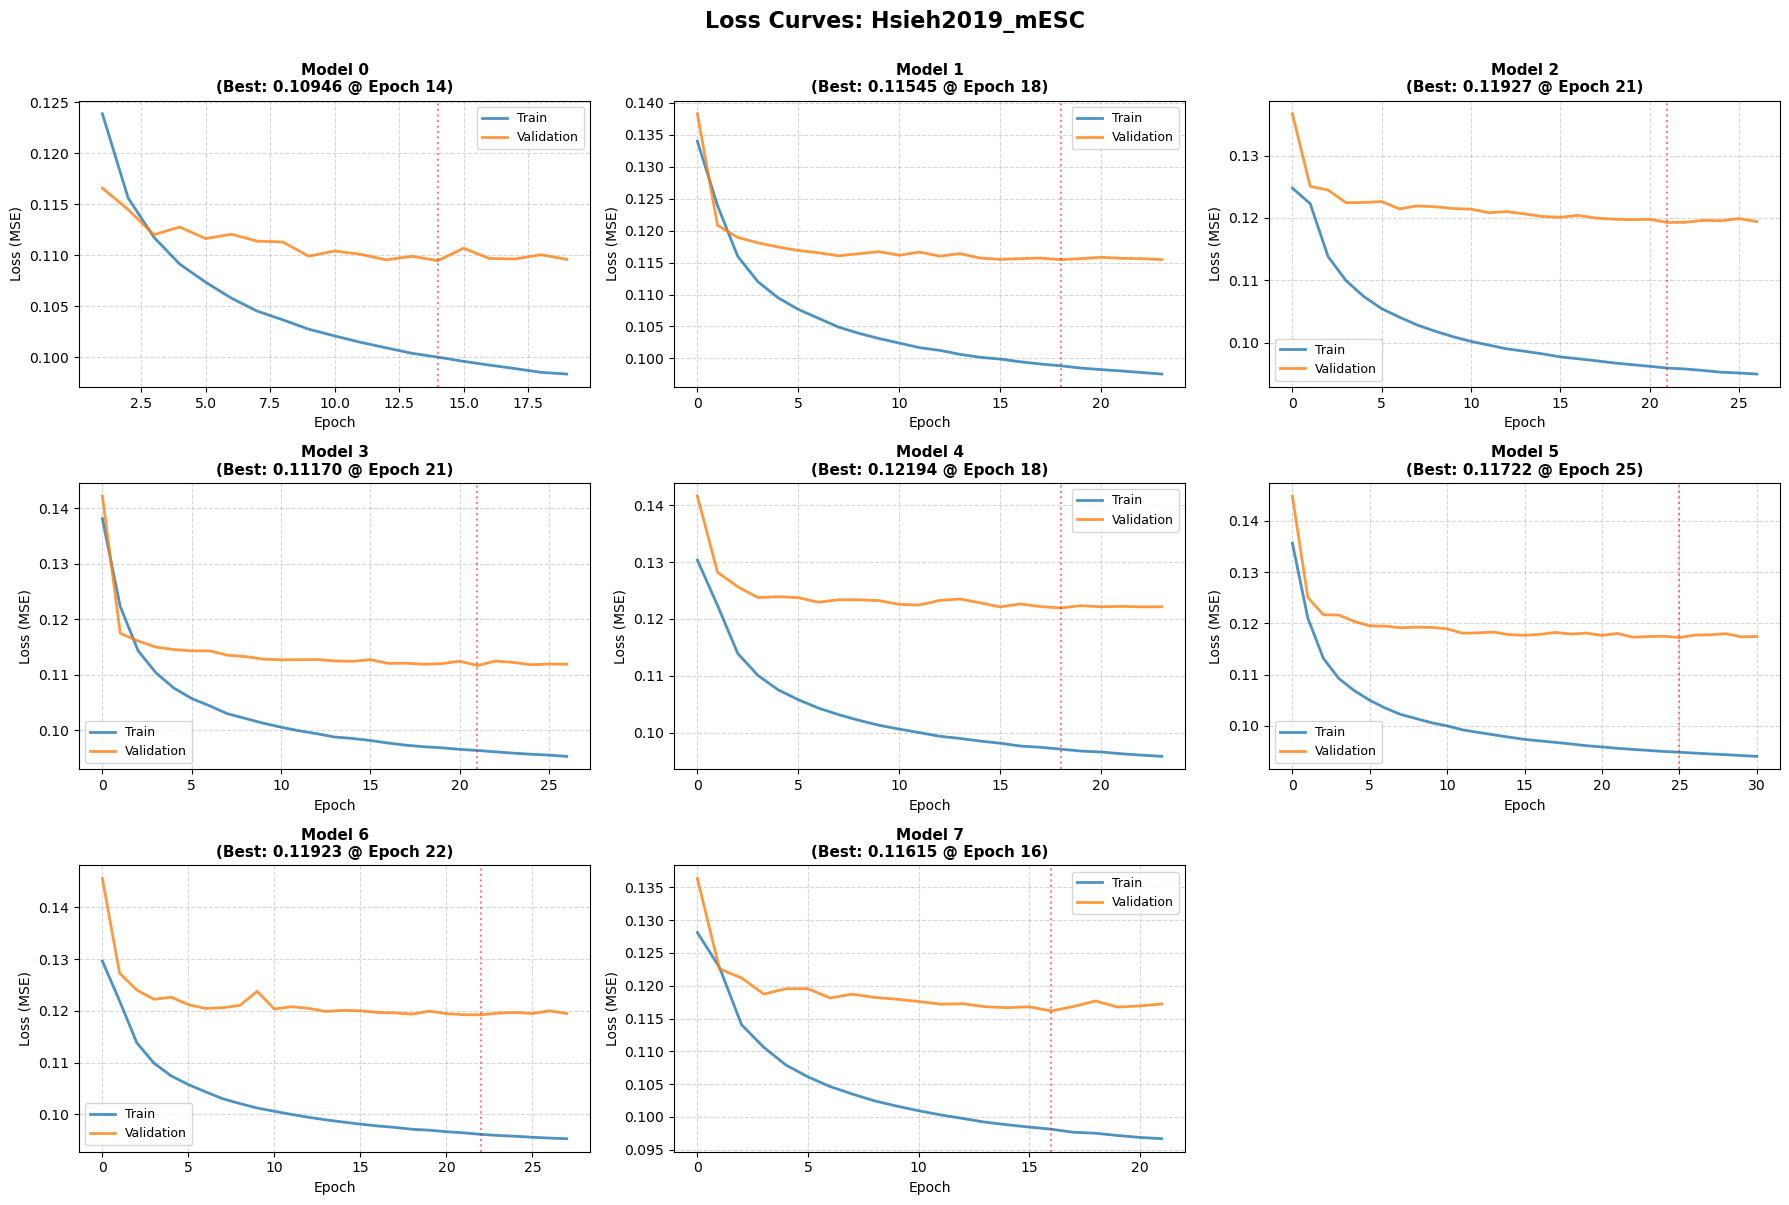

In [5]:
print("="*70)
print("Analyzing Fine-tuning Loss Curves")
print("="*70)
print(f"Organism: {ORGANISM}")
print(f"Dataset: {DATASET_NAME}")
print("")

if PLOT_SINGLE:
    # Plot single model
    print(f"Plotting single model: {SINGLE_MODEL_IDX}")
    df = load_loss_file(ORGANISM, DATASET_NAME, SINGLE_MODEL_IDX, BASE_PATH)

    if df is not None:
        plot_single_model(df, SINGLE_MODEL_IDX, DATASET_NAME)

        if SAVE_FIGURE:
            plt.savefig(OUTPUT_FILE, format='svg', bbox_inches='tight')
            print(f"\n✓ Figure saved to: {OUTPUT_FILE}")
    else:
        print(f"Error: Could not load data for model {SINGLE_MODEL_IDX}")

else:
    # Plot all models
    print("Finding all available models...")
    model_indices = find_all_models(ORGANISM, DATASET_NAME, BASE_PATH)

    if not model_indices:
        print(f"Warning: No models found. Trying models 0 to {NUM_MODELS-1}...")
        model_indices = list(range(NUM_MODELS))
    else:
        print(f"Found {len(model_indices)} models: {model_indices}")

    print("")
    plot_all_models(ORGANISM, DATASET_NAME, model_indices, BASE_PATH)

    if SAVE_FIGURE:
        plt.savefig(OUTPUT_FILE, format='svg', bbox_inches='tight')
        print(f"\n✓ Figure saved to: {OUTPUT_FILE}")

print("\nDone!")
